**Experiment 5: Text Generation using GPT-2 and Decoding Parameters**

Aim:
    Generate text and study the effect of decoding parameters
    (greedy decoding, temperature, top-k, top-p).

In [1]:
import os
import time
import torch
import pandas as pd
from transformers import GPT2LMHeadModel, GPT2Tokenizer, set_seed

In [2]:
# STEP 1: Load GPT-2 locally
MODEL_NAME = "gpt2"   # smallest GPT-2 variant (124M params) -- fast to load

print(f"[Step 1] Loading model & tokenizer: {MODEL_NAME} ...")
tokenizer = GPT2Tokenizer.from_pretrained(MODEL_NAME)
model = GPT2LMHeadModel.from_pretrained(MODEL_NAME)
model.eval()

device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)
print(f"[Step 1] Model loaded on device: {device}")

[Step 1] Loading model & tokenizer: gpt2 ...


tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

...

model.safetensors: reconstructing file:   0%|          |  0.00B /  548MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

[Step 1] Model loaded on device: cpu


In [3]:
# GPT-2 has no pad token by default; reuse eos_token as pad_token
tokenizer.pad_token = tokenizer.eos_token

In [4]:
# STEP 2: Create one fixed prompt and keep it unchanged
default_prompt = "Artificial intelligence will change the future of education by"

user_prompt = input(
    f"\n[Step 2] Enter a prompt (Enter for default:\n'{default_prompt}'): \n> "
).strip()
prompt = user_prompt if user_prompt else default_prompt
print(f"\n[Step 2] Fixed prompt for this whole experiment: \"{prompt}\"")

input_ids = tokenizer.encode(prompt, return_tensors="pt").to(device)

MAX_NEW_TOKENS = 40   # keep generation length fixed across all settings
SEED = 42              # fix seed so sampling runs are still reproducible per-run

results = []   # will hold rows for the summary table


def generate_and_record(setting_name, gen_kwargs):
    """Run model.generate with given kwargs, time it, and store the result."""
    set_seed(SEED)  # reproducibility for sampling-based methods
    start = time.time()
    with torch.no_grad():
        output_ids = model.generate(
            input_ids,
            max_new_tokens=MAX_NEW_TOKENS,
            pad_token_id=tokenizer.eos_token_id,
            **gen_kwargs,
        )
    elapsed_ms = (time.time() - start) * 1000

    generated_text = tokenizer.decode(output_ids[0], skip_special_tokens=True)
    new_text_only = generated_text[len(prompt):].strip()
    num_unique_words = len(set(new_text_only.lower().split()))
    num_words = len(new_text_only.split())

    results.append({
        "setting": setting_name,
        "params": str(gen_kwargs),
        "output_word_count": num_words,
        "unique_word_count": num_unique_words,
        "gen_time_ms": round(elapsed_ms, 1),
        "generated_text": new_text_only,
    })

    print(f"\n--- {setting_name} ---")
    print(f"Params: {gen_kwargs}")
    print(f"Output: {new_text_only}")
    return new_text_only


[Step 2] Enter a prompt (Enter for default:
'Artificial intelligence will change the future of education by'): 
> Artificial intelligence will change the future of education by

[Step 2] Fixed prompt for this whole experiment: "Artificial intelligence will change the future of education by"


In [5]:
# STEP 3: Generate text using deterministic/greedy decoding
print("\n[Step 3] Greedy (deterministic) decoding — always picks the single "
      "highest-probability next token.")
generate_and_record("Greedy (do_sample=False)", {"do_sample": False})


[Step 3] Greedy (deterministic) decoding — always picks the single highest-probability next token.

--- Greedy (do_sample=False) ---
Params: {'do_sample': False}
Output: making it possible for students to learn from their peers.

"We are seeing a lot of innovation in the field of artificial intelligence," said Dr. David S. Siegel, a professor of


'making it possible for students to learn from their peers.\n\n"We are seeing a lot of innovation in the field of artificial intelligence," said Dr. David S. Siegel, a professor of'

In [6]:
# STEP 4: Generate outputs with different temperature values
print("\n[Step 4] Sampling with different temperature values "
      "(temperature scales the logits before softmax; controls randomness).")

temperatures = [0.3, 0.7, 1.0, 1.5]
for temp in temperatures:
    generate_and_record(
        f"Temperature={temp}",
        {"do_sample": True, "temperature": temp, "top_k": 0, "top_p": 1.0},
    )


[Step 4] Sampling with different temperature values (temperature scales the logits before softmax; controls randomness).

--- Temperature=0.3 ---
Params: {'do_sample': True, 'temperature': 0.3, 'top_k': 0, 'top_p': 1.0}
Output: creating a new generation of teachers with the skills and knowledge to help students succeed.

The new generation of teachers will be able to teach students from an early age and will be able to teach them

--- Temperature=0.7 ---
Params: {'do_sample': True, 'temperature': 0.7, 'top_k': 0, 'top_p': 1.0}
Output: transforming our education system into a workplace where more and more students are learning and learning and learning.

Can we do this?

Laws requiring public school teachers to be trained in artificial intelligence

--- Temperature=1.0 ---
Params: {'do_sample': True, 'temperature': 1.0, 'top_k': 0, 'top_p': 1.0}
Output: transforming our education system into one in which more resources are accessible to students and teachers and would create a new qual

In [7]:
# STEP 5: Repeat using top-k or top-p
print("\n[Step 5] Sampling with top-k (restrict to k most probable tokens).")
for k in [10, 50]:
    generate_and_record(
        f"Top-k={k} (temperature=1.0)",
        {"do_sample": True, "temperature": 1.0, "top_k": k, "top_p": 1.0},
    )

print("\n[Step 5] Sampling with top-p / nucleus sampling "
      "(sample from smallest set of tokens whose cumulative prob >= p).")
for p in [0.5, 0.9]:
    generate_and_record(
        f"Top-p={p} (temperature=1.0)",
        {"do_sample": True, "temperature": 1.0, "top_k": 0, "top_p": p},
    )


[Step 5] Sampling with top-k (restrict to k most probable tokens).

--- Top-k=10 (temperature=1.0) ---
Params: {'do_sample': True, 'temperature': 1.0, 'top_k': 10, 'top_p': 1.0}
Output: transforming our education system into one in which children will be educated in their own best interest."

"There's a great deal of uncertainty about how much of what you can learn in our schools will

--- Top-k=50 (temperature=1.0) ---
Params: {'do_sample': True, 'temperature': 1.0, 'top_k': 50, 'top_p': 1.0}
Output: transforming our education system into one in which more resources are accessible to students and teachers and students become smarter. The research team is now conducting further research into the potential of artificial intelligence to improve our educational systems

[Step 5] Sampling with top-p / nucleus sampling (sample from smallest set of tokens whose cumulative prob >= p).

--- Top-p=0.5 (temperature=1.0) ---
Params: {'do_sample': True, 'temperature': 1.0, 'top_k': 0, 'top_p': 0.

In [8]:
# STEP 6-7: Record & compare output diversity, coherence, length
df = pd.DataFrame(results)
print("\n[Step 6-7] Summary table of all decoding settings:\n")
pd.set_option("display.max_colwidth", 60)
print(df[["setting", "output_word_count", "unique_word_count", "gen_time_ms"]]
      .to_string(index=False))

print("""
[Step 6-7] How to read this table when writing your report:
  - output_word_count / unique_word_count -> higher unique-word ratio
    generally suggests more lexical diversity (though not necessarily more
    coherence).
  - Compare the actual generated_text for each row (printed above) to judge
    COHERENCE manually -- low temperature / low top-k / low top-p should
    read more repetitive but "safe" and grammatical; high temperature /
    high top-p should read more varied but occasionally less coherent or
    even nonsensical.
  - Greedy decoding is deterministic: running it again with the exact same
    prompt and model will always give the exact same output.
""")


[Step 6-7] Summary table of all decoding settings:

                    setting  output_word_count  unique_word_count  gen_time_ms
   Greedy (do_sample=False)                 31                 28       3258.7
            Temperature=0.3                 37                 24       2721.4
            Temperature=0.7                 33                 29       3027.0
            Temperature=1.0                 37                 33       3450.5
            Temperature=1.5                 30                 30       3063.9
 Top-k=10 (temperature=1.0)                 35                 30       3051.8
 Top-k=50 (temperature=1.0)                 39                 32       2754.7
Top-p=0.5 (temperature=1.0)                 33                 29       4915.3
Top-p=0.9 (temperature=1.0)                 37                 34       3266.7

[Step 6-7] How to read this table when writing your report:
  - output_word_count / unique_word_count -> higher unique-word ratio
    generally suggests mor

In [9]:
# Full generated texts (for pasting into your report / observation table)
print("\n[Full generated texts per setting]\n")
for row in results:
    print(f"### {row['setting']}")
    print(f"{row['generated_text']}\n")


[Full generated texts per setting]

### Greedy (do_sample=False)
making it possible for students to learn from their peers.

"We are seeing a lot of innovation in the field of artificial intelligence," said Dr. David S. Siegel, a professor of

### Temperature=0.3
creating a new generation of teachers with the skills and knowledge to help students succeed.

The new generation of teachers will be able to teach students from an early age and will be able to teach them

### Temperature=0.7
transforming our education system into a workplace where more and more students are learning and learning and learning.

Can we do this?

Laws requiring public school teachers to be trained in artificial intelligence

### Temperature=1.0
transforming our education system into one in which more resources are accessible to students and teachers and would create a new quality for learning. For this reason ACM has become its own institution. Its members go to

### Temperature=1.5
solidifying importance to t

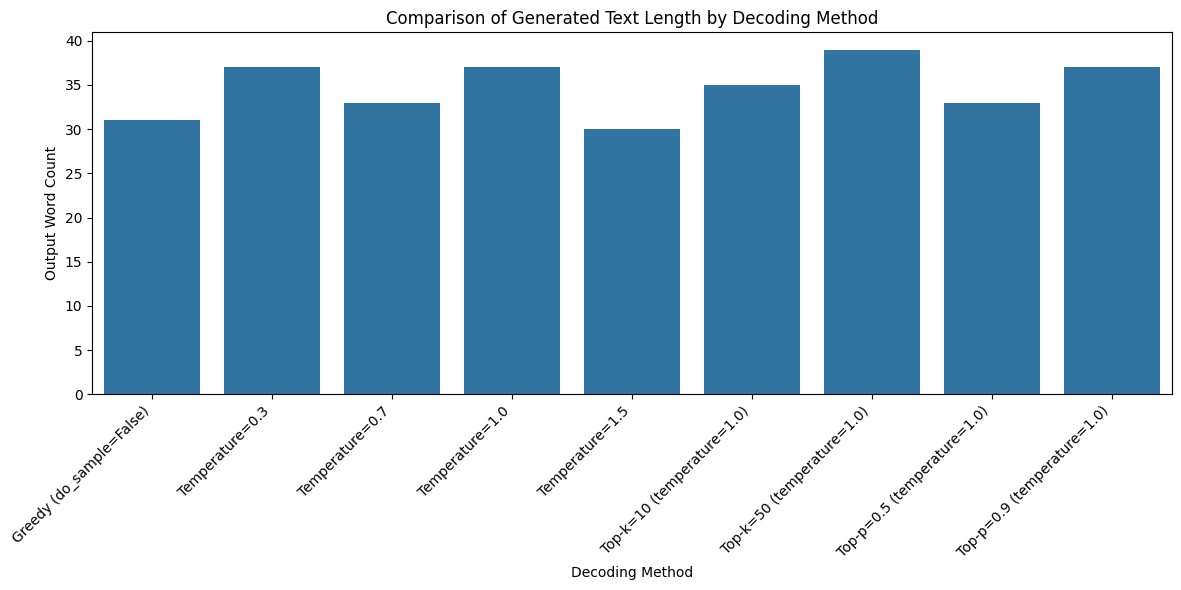

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.barplot(x='setting', y='output_word_count', data=df)
plt.xlabel('Decoding Method')
plt.ylabel('Output Word Count')
plt.title('Comparison of Generated Text Length by Decoding Method')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()